In [34]:
import numpy
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Data

In [35]:
california_csv = numpy.genfromtxt('californiabin.csv', delimiter=',')

train_part = int(california_csv.shape[0] * 0.8)
test_part = california_csv.shape[0] - train_part

X_train = california_csv[:train_part, :-1]
y_train = california_csv[:train_part, -1]

X_test = california_csv[-test_part:, :-1]
y_test = california_csv[-test_part:, -1]


# K-fold 

In [36]:
def kFoldsTrain(k, X_train_folds, y_train_folds, model):
    from sklearn.base import clone

    X_folds = numpy.array_split(X_train_folds, k)
    y_folds = numpy.array_split(y_train_folds, k)
    scores = []

    for i in range(k):
        X_train_fold = numpy.concatenate([fold for j, fold in enumerate(X_folds) if j != i])
        y_train_fold = numpy.concatenate([fold for j, fold in enumerate(y_folds) if j != i])
        X_validation_fold = X_folds[i]
        y_validation_fold = y_folds[i]

        fold_model = clone(model)
        fold_model.fit(X_train_fold, y_train_fold)
        scores.append(fold_model.score(X_validation_fold, y_validation_fold))

    return numpy.mean(scores)


# SVM train

In [37]:
# SVM GridSearch
C_exponents = [-5, -3, -1, 1, 3, 5, 7, 9, 11, 13, 15]
gamma_exponents = [-15, -13, -11, -9, -7, -5, -3, -1, 1, 2, 3]
C_values = [2 ** exponent for exponent in C_exponents]
gamma_values = [2 ** exponent for exponent in gamma_exponents]
best_score_svm = -1
best_params_svm = [] # C, gamma
svm_best_model = None

for C in C_values:
    for gamma in gamma_values:
        model = SVC(C=C, gamma=gamma, kernel="rbf")
        
        score_mean = kFoldsTrain(10, X_train, y_train, model)
        if score_mean > best_score_svm: 
            best_score_svm = score_mean
            best_params_svm = [C, gamma]
            svm_best_model = clone(model)

svm_best_model = SVC(C=best_params_svm[0], gamma=best_params_svm[1], kernel="rbf")
svm_best_model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",32768
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",3.0517578125e-05
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# Random Forest train

In [38]:
# Random Forest GridSearch
n_estimators_values = list(range(10, 201, 10))
max_depth_values = [4, 6, 8, 10, None]
best_score_random_forest = -1
best_params_random_forest = [] # n_estimators, max_depth
random_forest_best_model = None

for n_estimators in n_estimators_values:
    for depth in max_depth_values:
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=depth, random_state=42)
        
        score_mean = kFoldsTrain(10, X_train, y_train, model)
        if score_mean > best_score_random_forest: 
            best_score_random_forest = score_mean
            best_params_random_forest = [n_estimators, depth]
            random_forest_best_model = clone(model)

random_forest_best_model = RandomForestClassifier(
    n_estimators=best_params_random_forest[0],
    max_depth=best_params_random_forest[1],
    random_state=42,
)
random_forest_best_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",40
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

# Metrics (part b)

## Metrics helper

In [39]:
def model_test_metrics(model_name, model, best_params, param_names):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        positive_class_index = list(model.classes_).index(1)
        y_score = model.predict_proba(X_test)[:, positive_class_index]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "Acuracia": accuracy_score(y_test, y_pred),
        "Revocacao": recall_score(y_test, y_pred, zero_division=0),
        "Precisao": precision_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, y_score),
        "AUPRC": average_precision_score(y_test, y_score),
    }

    print(model_name)
    print("Hiperparametros selecionados:")
    for param_name, param_value in zip(param_names, best_params):
        print(f"  {param_name}: {param_value}")

    print("Metricas nos dados de teste:")
    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    RocCurveDisplay.from_predictions(y_test, y_score, name=model_name, ax=axes[0])
    axes[0].set_title(f"ROC - {model_name}")
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=model_name, ax=axes[1])
    axes[1].set_title(f"Precision-Recall - {model_name}")
    plt.tight_layout()
    plt.show()

    return metrics


## SVM best model

SVM
Hiperparametros selecionados:
  C: 32768
  gamma: 3.0517578125e-05
Metricas nos dados de teste:
  Acuracia: 0.7975
  Revocacao: 0.8173
  Precisao: 0.7816
  F1-score: 0.7990
  AUROC: 0.8595
  AUPRC: 0.8109


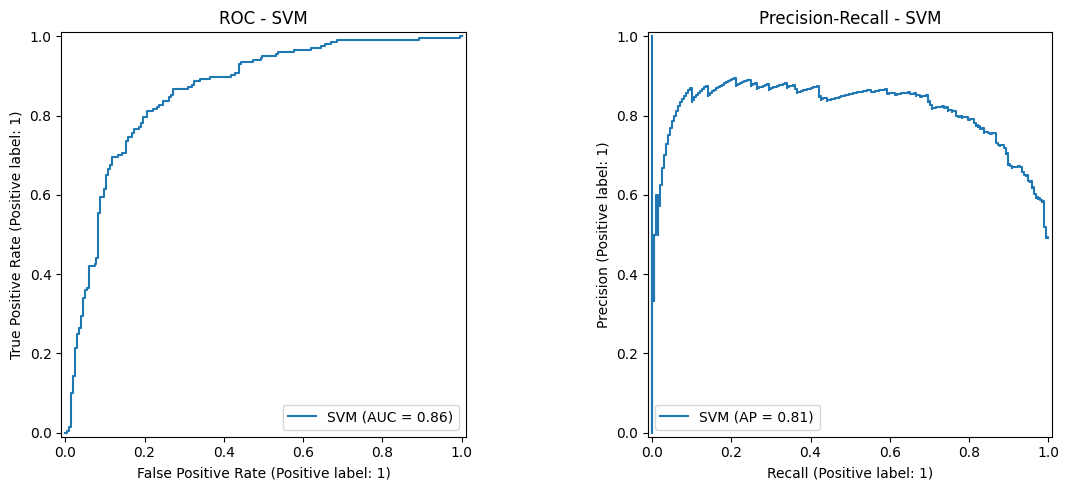

In [40]:
svm_metrics = model_test_metrics(
    "SVM",
    svm_best_model,
    best_params_svm,
    ["C", "gamma"],
)


## Random Forest best model

Random Forest
Hiperparametros selecionados:
  n_estimators: 40
  max_depth: 10
Metricas nos dados de teste:
  Acuracia: 0.8725
  Revocacao: 0.8782
  Precisao: 0.8650
  F1-score: 0.8715
  AUROC: 0.9336
  AUPRC: 0.9379


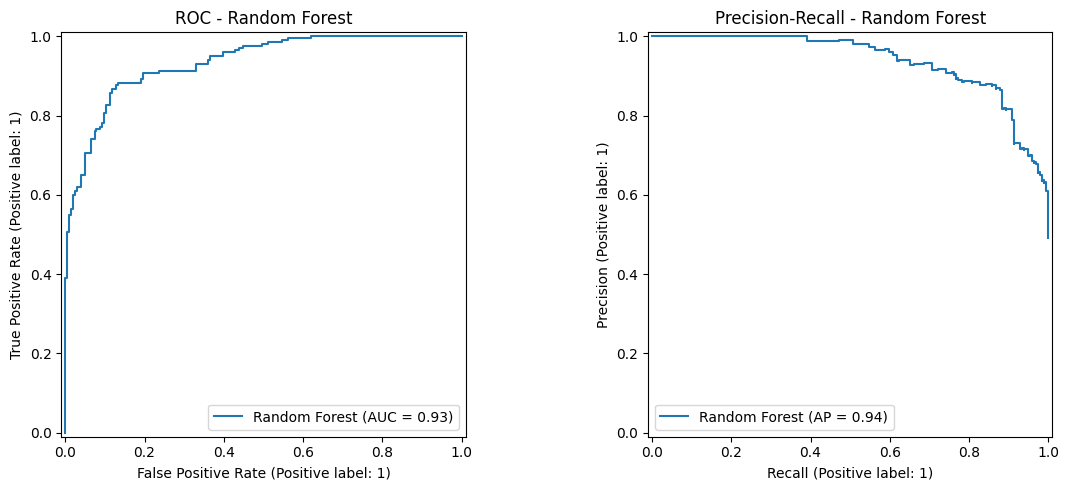

In [41]:
random_forest_metrics = model_test_metrics(
    "Random Forest",
    random_forest_best_model,
    best_params_random_forest,
    ["n_estimators", "max_depth"],
)


# Final train

## SVM final train

In [42]:
X_total = california_csv[:, :-1]
y_total = california_csv[:, -1]

In [43]:
svm_final_model = SVC(C=best_params_svm[0], gamma=best_params_svm[1], kernel="rbf")
svm_final_model.fit(X_total, y_total)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",32768
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",3.0517578125e-05
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Random Forest final train

In [44]:
random_forest_final_model = RandomForestClassifier(
    n_estimators=best_params_random_forest[0],
    max_depth=best_params_random_forest[1],
    random_state=42,
)
random_forest_final_model.fit(X_total, y_total)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",40
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_